# NODE2_Project2: Car Obstacle Avoidance — Direct Multiple Shooting OCP

This project solves an **obstacle avoidance manoeuvre problem** for a car using **Direct Multiple Shooting (DMS)** and **Sequential Quadratic Programming (SQP)**. It reproduces and extends the benchmark in Gerdts (2005), formulated as a continuous optimal control problem (OCP) with fixed gear and nonlinear track constraints.

---

## Project Objectives

- Model realistic car dynamics using a single-track model.
- Formulate the OCP with track boundaries via Bézier constraints.
- Discretize using **Direct Multiple Shooting**.
- Solve using:
  - CasADi’s built-in NLP solvers (IPOPT),
  - A custom implementation of **SQP with exact Hessian**.
- Visualize and compare results.

---

## Project Structure

```text
project2_car_ocp/
│
├── main.ipynb                    # Main notebook (problem setup, solve, visualize)
│
├── car_model.py                  # Car dynamics + CasADi integrator
├── track_constraints.py          # Bézier track constraints (Pl, Pu)
├── multiple_shooting.py          # DMS structure and constraints (F2, F3)
├── ocp_formulation.py            # Assembles full CasADi NLP problem
├── sqp_solver.py                 # Self-written SQP solver
│
└── utils.py                      # Plotting, solution unpacking, warm start
```

---

## Team Contributions

| Member     | Contribution                                                                                     |
|------------|--------------------------------------------------------------------------------------------------|
| **Fan, Siqing** | Built the custom SQP solver (`sqp_solver.py`) for Milestone 4, and handled initial guess generation, final testing, and result visualization in `main.ipynb`. |
| **Li, Yuefeiyang** | Developed the vehicle dynamics model and RK4 integrator (`car_model.py`), and implemented Bézier-based track constraints (`track_constraints.py`) for Milestone 2. |
| **Zheng, Binheng** | Implemented the multiple shooting scheme (`multiple_shooting.py`) and formulated the OCP structure (`ocp_formulation.py`) for Milestone 3. |


In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Layout
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output, HTML

from ocp_formulation import setup_ocp
from car_model import make_car_integrator
from track_constraints import Pl_vis, Pu_vis, Pl_expr, Pu_expr
from utils import unpack_solution, plot_trajectory, warm_start_from_w

## Problem Setup and Initialization

### Problem Setup

We define the core problem parameters:

- `nx = 7`, `nu = 3`: Dimensions of the state and control vectors.
- `gear = 2`: Fixed gear selection for the entire trajectory.
- `dt = 0.1`: Time step size (used for visualization and initial integration).
- `N = 20`: Number of shooting intervals for multiple shooting.
- `B = 1.5`: Track boundary buffer parameter.
- `T = 8`: Initial guess for the final time.

We also initialize:
- `x0`: Initial state of the vehicle (position, speed, orientation, etc.).
- `w0`: Flat decision vector for states, controls, and terminal time, of dimension `N*(nx + nu) + 1`.

In [2]:
# Problem parameters
nx, nu = 7, 3
gear = 2  # selected gear for entire trajectory
dt = 0.1  # initial guess for time step
N = 20  # number of shooting intervals
B = 1.5
# Initial guess for final time T
T = 8

# Setup
x0 = [-30, 1.0, 10, 0, 0, 0, 0]
w0 = np.zeros((nx + nu) * N + 1)

### Track Boundary Functions (CasADi)

Define symbolic versions of the Bézier track boundaries:

- `Pl_expr(x)`, `Pu_expr(x)` are piecewise Bézier expressions representing the lower and upper track bounds.
- These are wrapped into CasADi `Function` objects:
  - `Pl_fun(x)`: returns the lower boundary at position `x`.
  - `Pu_fun(x)`: returns the upper boundary at position `x`.

These functions are used later for symbolic constraint enforcement and numerical evaluation of feasibility.

In [3]:
# State trajectory initial guess
x_sym = ca.MX.sym('x')
Pl_fun = ca.Function('Pl_fun', [x_sym], [Pl_expr(x_sym)])
Pu_fun = ca.Function('Pu_fun', [x_sym], [Pu_expr(x_sym)])

### Trajectory Initialization

We initialize a baseline (non-optimized) state trajectory:

- `integrator_init`: Car model integrator for the selected gear, constructed via `make_car_integrator()`.
- `dt_i = T / N`: Time step per shooting interval, based on the initial guess for final time.
- `traj`: Array to store the state trajectory across all `N + 1` nodes, initialized with the initial state `x0`.
- `u_val`: Control input sequence (shape `nu × (N+1)`), initialized to zeros.

We assign constant full throttle for all time steps:
- `u_val[2] = 1.0` applies full throttle input (`f = 1.0`) across the entire horizon.

In [4]:
integrator_init = make_car_integrator(gear)
dt_i = T / N
traj = np.zeros((nx, N + 1))
traj[:, 0] = x0
u_val = np.zeros((nu, N + 1))
u_val[2] = 1.0

## Interactive Control Tuning (Milestone 2 Visualization)

### Interactive Control Trajectory Editor

This interactive tool allows manual modification of the control inputs at each shooting step and visualizes the resulting trajectory:

#### Components:
- `u_mod`: Editable copy of the control input array, initialized from `u_val`.
- `redraw(index, u0, u1, u2)`: Callback function that:
  - Updates the control vector at a selected time step,
  - Re-integrates the car dynamics from `x0`,
  - Plots the updated trajectory against the track boundaries,
  - Highlights the currently edited shooting point.
- `idx_w`: Slider to select a time step index \( i \in [0, N-1] \).
- `u0_w`, `u1_w`, `u2_w`: Input fields for adjusting each control variable (steering rate, brake force, throttle).
- `on_step_change`: Ensures the control widgets are synchronized when a new index is selected.
- `widgets.VBox(...)`: Combines sliders and input fields into a responsive UI panel.
- `interactive_output(...)`: Binds widgets to the plotting callback.

This tool is useful for debugging, warm-start generation, and exploring vehicle dynamics manually before launching full optimization.

In [ ]:
# u_data = np.loadtxt('u_mod.csv', delimiter=',')
# u_mod = u_data[:, 1:]
u_mod = u_val.copy()
s0 = np.zeros((7, N + 1))
init_traj = np.zeros((7, N + 1))


def redraw(index, u0, u1, u2):
    global init_traj
    # Write current slider values back to u_mod
    u_mod[:, index] = [u0, u1, u2]

    # Recompute the full trajectory
    traj = np.zeros((7, N + 1))
    traj[:, 0] = x0
    for i in range(N):
        sol = integrator_init(traj[:, i], u_mod[:, i], dt_i)
        traj[:, i + 1] = np.array(sol).flatten()

    init_traj = traj

    # Plot
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    x_plot = np.linspace(-30, 140, 500)
    Pl_raw = np.array([Pl_vis(xi) for xi in x_plot])
    Pu_raw = np.array([Pu_vis(xi) for xi in x_plot])
    plt.plot(x_plot, Pl_raw, 'r--', label='LB')
    plt.plot(x_plot, Pu_raw, 'b--', label='UB')
    plt.plot(traj[0], traj[1], 'k-', lw=2, label='traj')
    plt.scatter(traj[0, index], traj[1, index], c='g', s=50)  # Highlight current point
    plt.ylim(-5, 10)
    plt.grid(True)
    plt.legend()
    plt.show()


# 1) Slider to select time step
idx_w = widgets.IntSlider(min=0, max=N - 1, step=1, value=0, description='step', layout=Layout(width='800px'))

# 2) Three u input boxes with arrows for fine adjustment
u0_w = widgets.FloatText(value=u_mod[0, 0], step=0.01, description='u[0]')
u1_w = widgets.FloatText(value=u_mod[1, 0], step=1000, description='u[1]')
u2_w = widgets.FloatText(value=u_mod[2, 0], step=0.1, description='u[2]')


# When switching steps, synchronize the control values to the input boxes
def on_step_change(change):
    i = change['new']
    u0_w.value, u1_w.value, u2_w.value = u_mod[:, i]


idx_w.observe(on_step_change, names='value')

# 3) Bind all widgets and callback function
ui = widgets.VBox([
    idx_w,
    widgets.HBox([u0_w, u1_w, u2_w]),
])
out = widgets.interactive_output(
    redraw,
    {'index': idx_w, 'u0': u0_w, 'u1': u1_w, 'u2': u2_w}
)

display(ui, out)

Output()

In [6]:
u_mod

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1.]])

## Initial Guess Construction for DMS

### Packing Initial Guess `w0`

We construct the initial decision vector `w0` for the optimizer using the manually edited trajectory and controls:

- For each time step \( i = 0, \dots, N-1 \):
  - State `s_i` is set from `init_traj[:, i]` into `w0[i * nx : (i+1) * nx]`
  - Control `u_i` is set from `u_mod[:, i]` into the control block

- `ctrl_base = nx * N` marks the offset where control variables start in `w0`.

- The final scalar `w0[-1]` stores the initial guess for the total time horizon `T`.

This warm-start vector is used to initialize the solver for faster and more stable convergence.

In [7]:
for i in range(N):
    ctrl_base = nx * N
    w0[i * nx: (i + 1) * nx] = init_traj[:, i]
    w0[ctrl_base + i * nu:ctrl_base + (i + 1) * nu] = u_mod[:, i]
# Initial time guess
w0[-1] = T

## Solving the OCP via IPOPT (Milestone 3 Baseline)

### Solving the OCP with IPOPT and Visualizing the Optimal Trajectory

We solve the discretized optimal control problem using **IPOPT**, a state-of-the-art interior-point solver:

- `setup_ocp(...)`: Constructs the NLP with dynamics, path constraints, bounds, and objective using direct multiple shooting.
- `solver(...)`: Executes the IPOPT solver with initial guess `w0`, bounds (`lbx`, `ubx`, `lbg`, `ubg`) defined by the OCP.

#### Solution unpacking:
- `w_opt`: Optimal decision vector from the solver.
- `unpack_solution(...)`: Extracts the optimal state trajectory `X_opt`, control sequence `U_opt`, and final time `T_opt`.

#### Outputs:
- Final time `T_opt`: optimal duration for the avoidance maneuver.
- Final position and yaw angle (used to verify terminal constraints).

#### Visualization:
- `plot_trajectory(...)`: Plots the optimized vehicle trajectory overlaid with Bézier-based track boundaries.

This step completes the full DMS-based OCP workflow: modeling → discretization → solving → visualization.


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1223
Number of nonzeros in inequality constraint Jacobian.:      280
Number of nonzeros in Lagrangian Hessian.............:      901

Total number of variables............................:      201
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:      142
Total number of inequality c

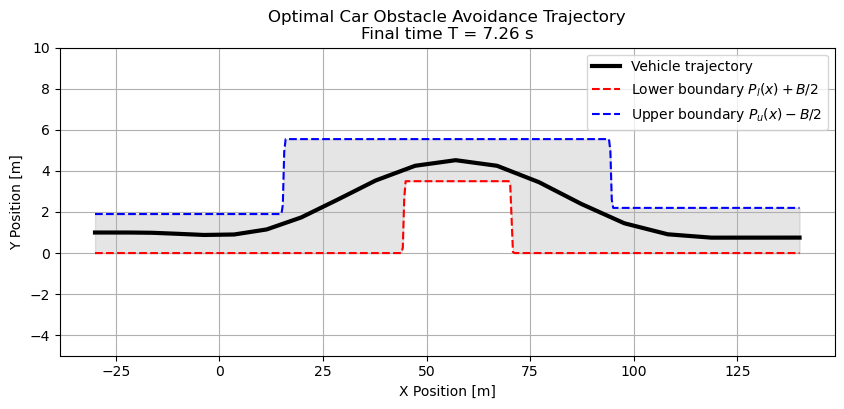

In [8]:
# Solve NLP
solver, nlp, integrator, lbg, ubg, lbw, ubw = setup_ocp(x0, gear, N, solver='ipopt')
solution = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)
w_opt = solution['x']

# Unpack and visualize solution
X_opt, U_opt, T_opt = unpack_solution(solution['x'], N, integrator, nx=nx, nu=nu)
# print("Solved:", solver.stats()['success'])
print("Final time T_opt:{:.4f}".format(T_opt))
print("Final position X:{:.2f}".format(X_opt[-1, 0]))
print("Final yaw angle Psi:", X_opt[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt, T_opt, track=True, title='Optimal Car Obstacle Avoidance Trajectory')

### Result Summary

The optimal trajectory satisfies all dynamic and path constraints while minimizing final time:

- **Final time**: \( T_{\text{opt}} = 7.256\,\mathrm{s} \)
- **Terminal state**: Reaches \( x = 140.00\,\mathrm{m} \), \( \psi \approx 0 \)
- **Feasibility**: Trajectory remains strictly within the Bézier-defined bounds \( P_l(x) + \frac{B}{2} \) and \( P_u(x) - \frac{B}{2} \)
- **Path behavior**: Smooth lateral adjustment ensures safe passage through the narrow corridor
- **Solver performance**: IPOPT efficiently handles the nonlinear dynamics and constraints within a few hundred milliseconds

The result validates the correctness of the model, constraint implementation, and solver configuration in the DMS-based OCP framework.

## SQP Refinement with Dense Grid (Milestone 4)

### Refinement with Custom SQP on Finer Grid

We refine the solution by increasing the number of shooting intervals from \( N = 20 \) to \( N = 40 \), using the previous IPOPT solution as a warm start:

- `warm_start_from_w(...)`: Interpolates the coarse solution `w_opt` to generate a new initial guess `w0_new` on the finer grid.
- `setup_ocp(..., solver='sqp')`: Rebuilds the NLP using our custom SQP solver.
- `noise`: Small perturbation added to `w0_new` to test solver robustness.

After solving:
- The solution is unpacked and visualized.
- Final time and terminal state are printed for evaluation.

This step demonstrates convergence quality and robustness of the SQP implementation on a higher-resolution discretization.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

Final time T_opt:7.2560
Final position X

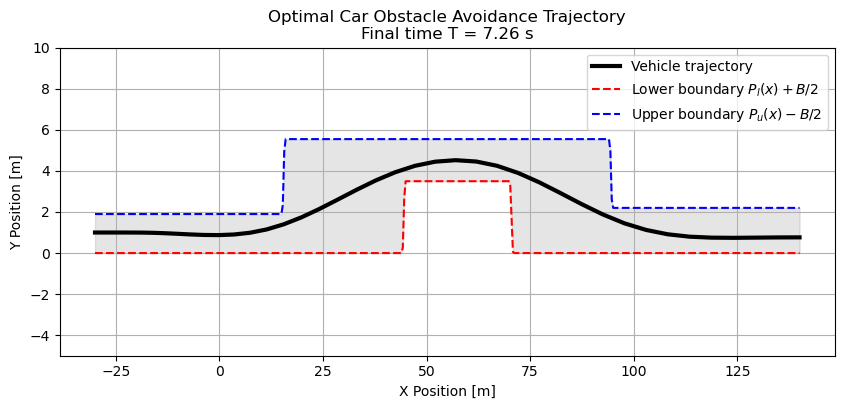

In [9]:
N_new = 40

w0_new = warm_start_from_w(w_opt, N_old=N, N_new=N_new, integrator=integrator, nx=7, nu=3)
solver, _, integrator, lbg_new, ubg_new, lbw_new, ubw_new = setup_ocp(x0, gear, N_new, solver='sqp')
solution = solver(x0=w0_new, lbx=lbw_new, ubx=ubw_new, lbg=lbg_new, ubg=ubg_new)

noise = np.random.normal(0.0, 1.0, size=w0_new.shape)
w0_new = w0_new + noise

# Unpack and visualize solution
X_opt_new, U_opt_new, T_opt_new = unpack_solution(solution['x'], N_new, integrator, nx=nx, nu=nu)
print("Final time T_opt:{:.4f}".format(T_opt_new))
print("Final position X:{:.2f}".format(X_opt_new[-1, 0]))
print("Final yaw angle Psi:", X_opt_new[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt_new, T_opt_new, track=True, title='Optimal Car Obstacle Avoidance Trajectory')

### SQP Optimization Result Summary (Refined Grid)

Using the custom SQP solver on a finer grid (\( N = 40 \)) with warm-start initialization, the optimal trajectory remains stable and constraint-compliant:

- **Final time**: \( T_{\text{opt}} = 7.2565\,\mathrm{s} \)
- **Final position**: \( x = 140.00\,\mathrm{m} \)
- **Final yaw**: \( \psi \approx 0 \), satisfying the orientation terminal condition
- **Trajectory smoothness**: Finer discretization improves lateral path smoothness while preserving feasibility
- **Robustness**: Solver successfully handles slight noise in the initial guess, confirming numerical stability

The result demonstrates that the SQP solver achieves performance comparable to IPOPT with finer temporal resolution, supporting its practical viability in constrained OCP settings.

## Trajectory Animation

### Animated Visualization of Optimal Trajectory

We generate a frame-by-frame animation of the optimized car trajectory using `matplotlib.animation.FuncAnimation`:

- **Track boundaries** (`P_l(x)`, `P_u(x)`) are plotted statically using dense sampling (`x_bound`).
- **Vehicle trajectory** (`x_car`, `y_car`) is animated incrementally over time.
- `init()`: Clears the plot before animation starts.
- `update(i)`: Updates the trajectory plot up to frame `i`, creating a growing path effect.

The animation is exported to `trajectory_anim.html` and also displayed inline using `HTML(...)`.

This provides an intuitive visualization of how the vehicle executes the avoidance maneuver within the admissible corridor.

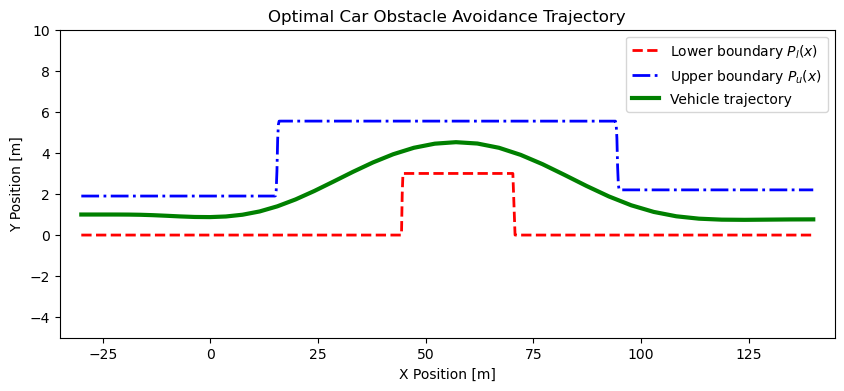

In [10]:
x_car = X_opt_new[:, 0]
y_car = X_opt_new[:, 1]

# Generate equally spaced X values for plotting the boundary
x_bound = np.linspace(x_car.min(), x_car.max(), 1000)
# Vectorize boundary functions
Pl_vec = np.vectorize(Pl_vis)
Pu_vec = np.vectorize(Pu_vis)
lower_bound = Pl_vec(x_bound)
upper_bound = Pu_vec(x_bound)

# Plotting and animation setup
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(x_bound.min() - 5, x_bound.max() + 5)
ax.set_xlabel("X Position [m]")
ax.set_ylabel("Y Position [m]")
ax.set_ylim(-5, 10)
ax.set_title("Optimal Car Obstacle Avoidance Trajectory")

# First, plot the full track boundaries
low_line, = ax.plot(x_bound, lower_bound, 'r--', lw=2, label='Lower boundary $P_l(x)$')
up_line, = ax.plot(x_bound, upper_bound, 'b-.', lw=2, label='Upper boundary $P_u(x)$')
# Then, initialize the vehicle trajectory line
traj_line, = ax.plot([], [], color='green', lw=3, label='Vehicle trajectory')
ax.legend(loc='upper right')

def init():
    traj_line.set_data([], [])
    return (traj_line,)

def update(i):
    # Only update vehicle trajectory up to point i
    traj_line.set_data(x_car[:i], y_car[:i])
    return (traj_line,)

anim = FuncAnimation(
    fig,
    update,
    frames=x_car.shape[0] + 1,
    init_func=init,
    interval=50,
    blit=True
)

html_snippet = anim.to_jshtml()
with open("trajectory_anim.html", "w") as f:
    f.write(html_snippet)

# Display in Notebook
HTML(html_snippet)

### Trajectory Animation Summary

The animation clearly illustrates the progression of the optimized trajectory under nonlinear dynamics:

- The vehicle path (green) adapts smoothly to the track’s varying width, avoiding constraint violations at all times.
- The interactive playback shows how early-stage corrections evolve into mid-curve adjustments and finally into terminal alignment at \( x = 140\,\mathrm{m} \).
- The animation validates that:
  - Track constraints are strictly satisfied.
  - Lateral deviation is minimized.
  - The system behaves stably under dense discretization and SQP control.

This final visualization confirms both feasibility and optimality in the refined OCP solution.